# Colab bootstrap

Run the cell below once after connecting to a new Colab runtime. It mounts Google Drive, clones or updates the repository, installs the project with the annotation-app dependencies, and configures the shared runtime paths.

In [1]:
from google.colab import drive
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = "https://github.com/terriljoel/retrieval-grounded-remote-sensing.git"
REPO_REF = "feat/object-detection-YOLO"  # Change to main after merging.
REPO_DIR = Path("/content/retrieval-grounded-remote-sensing")
SHARED_ROOT = Path("/content/drive/Othercomputers/My laptop/shared_resources")

drive.mount("/content/drive")

if (REPO_DIR / ".git").is_dir():
    subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin", REPO_REF], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "checkout", REPO_REF], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only", "origin", REPO_REF], check=True)
elif REPO_DIR.exists():
    raise RuntimeError(f"Repository path exists but is not a Git clone: {REPO_DIR}")
else:
    subprocess.run(
        ["git", "clone", "--branch", REPO_REF, REPO_URL, str(REPO_DIR)],
        check=True,
    )

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-e", f"{REPO_DIR}[annotation]"],
    check=True,
)

if not SHARED_ROOT.is_dir():
    raise FileNotFoundError(
        f"Shared resources were not found at {SHARED_ROOT}. "
        "Check the Google Drive computer and folder names."
    )

os.environ.update({
    "SHARED_RESOURCES_ROOT": str(SHARED_ROOT),
    "RAW_DATASET_ROOT": "/content/datasets/raw",
    "PROCESSED_DATASET_ROOT": "/content/datasets/processed",
    "MANIFEST_ROOT": str(SHARED_ROOT / "datasets" / "manifests"),
    "EXPERIMENT_OUTPUT_ROOT": str(SHARED_ROOT / "experiment_outputs"),
    "JOB_LOG_ROOT": str(SHARED_ROOT / "experiment_outputs" / "job_logs"),
    "INFERENCE_EXPORT_ROOT": str(SHARED_ROOT / "inference" / "object_detection_inference_new_remote_sensing_dataset_external-4"),
})

Path(os.environ["MANIFEST_ROOT"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["EXPERIMENT_OUTPUT_ROOT"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["JOB_LOG_ROOT"]).mkdir(parents=True, exist_ok=True)
os.chdir(REPO_DIR)

print(f"Ready. Working directory: {Path.cwd()}")
print("The detector commands and annotation app are ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready. Working directory: /content/retrieval-grounded-remote-sensing
The detector commands and annotation app are ready.


## Launch the annotation assistant (optional)

Run this cell only when you want to use the Streamlit app. It securely prompts for the NVIDIA API key when `NIM_API_KEY` is not already set, which also works when the Colab runtime is used through VS Code. The key remains only in the active runtime. The cell starts a temporary public Cloudflare URL; stop it with the following cell when finished.

In [2]:
from getpass import getpass
import re
import time

nim_api_key = os.environ.get("NIM_API_KEY", "").strip()
if not nim_api_key:
    nim_api_key = getpass("NVIDIA NIM API key: ").strip()
if not nim_api_key.startswith("nvapi-"):
    raise ValueError("The supplied NIM_API_KEY is not a valid NVIDIA API key")
os.environ["NIM_API_KEY"] = nim_api_key

checkpoint_root = SHARED_ROOT / "checkpoints"
checkpoints = sorted(checkpoint_root.rglob("*.pt"))
databases = list((SHARED_ROOT / "embeddings").glob("*/lancedb"))
if not checkpoints:
    raise FileNotFoundError(f"No .pt checkpoints found under: {checkpoint_root}")
print(f"Detector checkpoints available: {len(checkpoints)}")
for checkpoint in checkpoints:
    print(f"  - {checkpoint.relative_to(checkpoint_root)}")
if not databases:
    raise FileNotFoundError("No persisted LanceDB artifact was found")

cloudflared = Path("/content/cloudflared")
cloudflared_download = Path("/content/cloudflared.download")
cloudflared_url = (
    "https://github.com/cloudflare/cloudflared/releases/latest/"
    "download/cloudflared-linux-amd64"
)

def cloudflared_is_valid(path):
    if not path.is_file():
        return False
    try:
        result = subprocess.run(
            [str(path), "--version"],
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            timeout=15,
        )
    except (OSError, subprocess.SubprocessError):
        return False
    return "cloudflared version" in result.stdout.lower()

if not cloudflared_is_valid(cloudflared):
    cloudflared.unlink(missing_ok=True)
    cloudflared_download.unlink(missing_ok=True)
    print("Downloading cloudflared (automatic retries enabled)...")
    subprocess.run(
        [
            "curl",
            "--fail",
            "--location",
            "--retry",
            "5",
            "--retry-all-errors",
            "--connect-timeout",
            "30",
            "--output",
            str(cloudflared_download),
            cloudflared_url,
        ],
        check=True,
    )
    if cloudflared_download.stat().st_size < 10_000_000:
        raise RuntimeError("Downloaded cloudflared file is unexpectedly small")
    cloudflared_download.chmod(0o755)
    if not cloudflared_is_valid(cloudflared_download):
        raise RuntimeError("Downloaded cloudflared executable failed validation")
    cloudflared_download.replace(cloudflared)

for process_name in ("tunnel_process", "streamlit_process"):
    previous = globals().get(process_name)
    if previous is not None and previous.poll() is None:
        previous.terminate()

streamlit_log_path = Path("/content/streamlit.log")
tunnel_log_path = Path("/content/cloudflared.log")
streamlit_log_handle = streamlit_log_path.open("w")
streamlit_process = subprocess.Popen(
    [
        sys.executable, "-m", "streamlit", "run",
        "app/annotation_assistant.py",
        "--server.headless=true",
        "--server.address=127.0.0.1",
        "--server.port=8501",
        "--", "--config", "configs/annotation/single_image.yaml",
    ],
    cwd=REPO_DIR,
    env=os.environ.copy(),
    stdout=streamlit_log_handle,
    stderr=subprocess.STDOUT,
)
time.sleep(5)
if streamlit_process.poll() is not None:
    raise RuntimeError(streamlit_log_path.read_text(errors="replace"))

tunnel_log_handle = tunnel_log_path.open("w")
tunnel_process = subprocess.Popen(
    [str(cloudflared), "tunnel", "--url", "http://127.0.0.1:8501", "--no-autoupdate"],
    stdout=tunnel_log_handle,
    stderr=subprocess.STDOUT,
)

public_url = None
for _ in range(30):
    time.sleep(1)
    tunnel_output = tunnel_log_path.read_text(errors="replace")
    match = re.search(r"https://[A-Za-z0-9-]+\.trycloudflare\.com", tunnel_output)
    if match:
        public_url = match.group(0)
        break

if public_url is None:
    raise RuntimeError(tunnel_log_path.read_text(errors="replace"))
print(f"Open the annotation assistant: {public_url}")

Open the annotation assistant: https://earned-folder-monitors-instead.trycloudflare.com


In [3]:
for process_name in ("tunnel_process", "streamlit_process"):
    process = globals().get(process_name)
    if process is not None and process.poll() is None:
        process.terminate()
for handle_name in ("tunnel_log_handle", "streamlit_log_handle"):
    handle = globals().get(handle_name)
    if handle is not None and not handle.closed:
        handle.close()
print("Annotation assistant stopped.")

Annotation assistant stopped.


# Result Analysis


In [2]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


# These variables are already established by the bootstrap.
SHARED_ROOT = Path(os.environ["SHARED_RESOURCES_ROOT"])
EXPERIMENT_OUTPUT_ROOT = Path(
    os.environ["EXPERIMENT_OUTPUT_ROOT"]
)

DETECTION_ROOT = EXPERIMENT_OUTPUT_ROOT / "detection_test"
ASSISTANCE_ROOT = (
    EXPERIMENT_OUTPUT_ROOT
    / "assistance_comparisons"
)

print("Shared resources:", SHARED_ROOT)
print("Detection results:", DETECTION_ROOT)
print("Assistance results:", ASSISTANCE_ROOT)

assert SHARED_ROOT.is_dir()
assert DETECTION_ROOT.is_dir()
assert ASSISTANCE_ROOT.is_dir()

Shared resources: /content/drive/Othercomputers/My laptop/shared_resources
Detection results: /content/drive/Othercomputers/My laptop/shared_resources/experiment_outputs/detection_test
Assistance results: /content/drive/Othercomputers/My laptop/shared_resources/experiment_outputs/assistance_comparisons


In [3]:
BASELINE_DIR = (
    DETECTION_ROOT
    / "yolov8n_640_seed42_test"
)

FINAL_DETECTOR_DIR = (
    DETECTION_ROOT
    / "yolov8s_pretrained_1024_seed42_test"
)

NWPU_ASSISTANCE_DIR = (
    ASSISTANCE_ROOT
    / "nwpu_yolov8s1024_vlm_40_per_status_seed42_v2"
)

HRRSD_HIGH_DIR = (
    ASSISTANCE_ROOT
    / "hrrsd_yolov8s1024_vlm_highres_v2_seed42"
)

HRRSD_LOW_DIR = (
    ASSISTANCE_ROOT
    / "hrrsd_yolov8s1024_low_confidence_rescue_seed42"
)

RESULT_DIRECTORIES = {
    "YOLOv8n baseline": BASELINE_DIR,
    "YOLOv8s final detector": FINAL_DETECTOR_DIR,
    "NWPU assistance": NWPU_ASSISTANCE_DIR,
    "HRRSD high confidence": HRRSD_HIGH_DIR,
    "HRRSD low confidence": HRRSD_LOW_DIR,
}

for name, path in RESULT_DIRECTORIES.items():
    print(f"{name:25} {path.is_dir()}  {path}")

YOLOv8n baseline          True  /content/drive/Othercomputers/My laptop/shared_resources/experiment_outputs/detection_test/yolov8n_640_seed42_test
YOLOv8s final detector    True  /content/drive/Othercomputers/My laptop/shared_resources/experiment_outputs/detection_test/yolov8s_pretrained_1024_seed42_test
NWPU assistance           True  /content/drive/Othercomputers/My laptop/shared_resources/experiment_outputs/assistance_comparisons/nwpu_yolov8s1024_vlm_40_per_status_seed42_v2
HRRSD high confidence     True  /content/drive/Othercomputers/My laptop/shared_resources/experiment_outputs/assistance_comparisons/hrrsd_yolov8s1024_vlm_highres_v2_seed42
HRRSD low confidence      True  /content/drive/Othercomputers/My laptop/shared_resources/experiment_outputs/assistance_comparisons/hrrsd_yolov8s1024_low_confidence_rescue_seed42


## Compare baseline and final detector

In [4]:
def read_json(path):
    with path.open(encoding="utf-8") as file:
        return json.load(file)


baseline = read_json(
    BASELINE_DIR / "overall_test_metrics.json"
)
final_detector = read_json(
    FINAL_DETECTOR_DIR / "overall_metrics.json"
)

detector_comparison = pd.DataFrame([
    {
        "model": "YOLOv8n-640 baseline",
        "precision": baseline["precision"],
        "recall": baseline["recall"],
        "mAP50": baseline["mAP50"],
        "mAP50_95": baseline["mAP50_95"],
    },
    {
        "model": "YOLOv8s-1024 final",
        "precision": final_detector["precision"],
        "recall": final_detector["recall"],
        "mAP50": final_detector["mAP50"],
        "mAP50_95": final_detector["mAP50_95"],
    },
])

display(
    detector_comparison.style.format({
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "mAP50": "{:.3f}",
        "mAP50_95": "{:.3f}",
    })
)

,model,precision,recall,mAP50,mAP50_95
0,YOLOv8n-640 baseline,0.927,0.932,0.962,0.637
1,YOLOv8s-1024 final,0.932,0.920,0.956,0.659


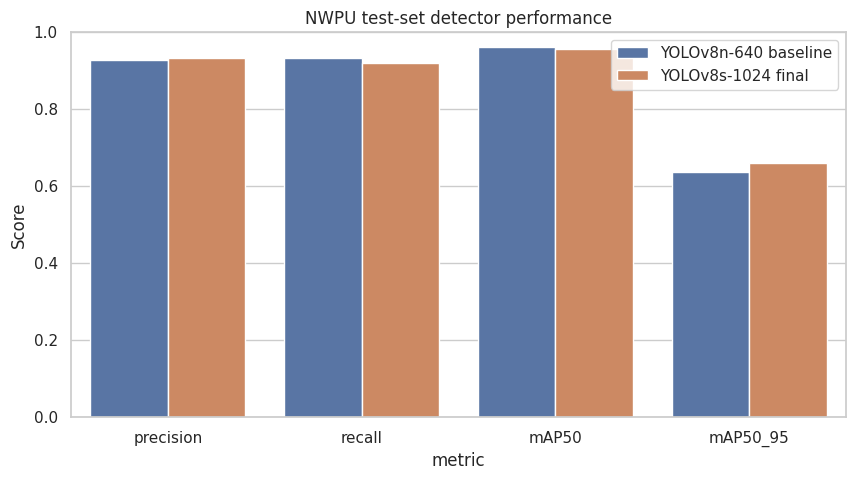

In [5]:
plot_data = detector_comparison.melt(
    id_vars="model",
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=plot_data,
    x="metric",
    y="value",
    hue="model",
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("NWPU test-set detector performance")
plt.legend(title="")
plt.show()

## Load Assistance Metrics

In [6]:
ASSISTANCE_RUNS = {
    "NWPU test": NWPU_ASSISTANCE_DIR,
    "HRRSD high confidence": HRRSD_HIGH_DIR,
    "HRRSD low confidence": HRRSD_LOW_DIR,
}

metric_frames = []

for run_name, run_directory in ASSISTANCE_RUNS.items():
    frame = pd.read_csv(run_directory / "metrics.csv")
    frame.insert(0, "experiment", run_name)
    metric_frames.append(frame)

assistance_metrics = pd.concat(
    metric_frames,
    ignore_index=True,
)

comparison_metrics = [
    "decision_accuracy",
    "auto_accept_coverage",
    "auto_accept_precision",
    "false_accept_rate",
    "class_correction_accuracy",
    "mean_latency_seconds",
]

metric_table = (
    assistance_metrics[
        assistance_metrics["metric"].isin(comparison_metrics)
    ]
    .pivot_table(
        index=["experiment", "variant"],
        columns="metric",
        values="value",
    )
    .reset_index()
)

display(metric_table.round(3))

metric,experiment,variant,auto_accept_coverage,auto_accept_precision,class_correction_accuracy,decision_accuracy,false_accept_rate,mean_latency_seconds
0,HRRSD high confidence,configured_policy,0.256,0.652,NaN,0.744,0.133,NaN
1,HRRSD high confidence,detector_only,1.000,0.333,NaN,0.333,1.000,NaN
2,HRRSD high confidence,detector_retrieval,0.522,0.617,NaN,0.789,0.300,0.171
3,HRRSD high confidence,query_only_vlm,0.589,0.566,0.800,0.744,0.383,26.771
4,HRRSD high confidence,retrieval_grounded_vlm,0.533,0.604,0.833,0.778,0.317,35.690
5,HRRSD low confidence,configured_policy,0.056,0.800,NaN,0.700,0.017,NaN
6,HRRSD low confidence,detector_only,0.000,NaN,NaN,0.667,0.000,NaN
7,HRRSD low confidence,detector_retrieval,0.000,NaN,NaN,0.667,0.000,0.166
8,HRRSD low confidence,query_only_vlm,0.489,0.682,0.800,0.844,0.233,28.222
9,HRRSD low confidence,retrieval_grounded_vlm,0.422,0.763,0.900,0.889,0.150,42.272


In [9]:
vlm_variants = [
    "query_only_vlm",
    "retrieval_grounded_vlm",
    "configured_policy",
]

# vlm_table = metric_table[
#     metric_table["variant"].isin(vlm_variants)
# ].copy()
vlm_table = metric_table

display(vlm_table.round(3))

metric,experiment,variant,auto_accept_coverage,auto_accept_precision,class_correction_accuracy,decision_accuracy,false_accept_rate,mean_latency_seconds
0,HRRSD high confidence,configured_policy,0.256,0.652,NaN,0.744,0.133,NaN
1,HRRSD high confidence,detector_only,1.000,0.333,NaN,0.333,1.000,NaN
2,HRRSD high confidence,detector_retrieval,0.522,0.617,NaN,0.789,0.300,0.171
3,HRRSD high confidence,query_only_vlm,0.589,0.566,0.800,0.744,0.383,26.771
4,HRRSD high confidence,retrieval_grounded_vlm,0.533,0.604,0.833,0.778,0.317,35.690
5,HRRSD low confidence,configured_policy,0.056,0.800,NaN,0.700,0.017,NaN
6,HRRSD low confidence,detector_only,0.000,NaN,NaN,0.667,0.000,NaN
7,HRRSD low confidence,detector_retrieval,0.000,NaN,NaN,0.667,0.000,0.166
8,HRRSD low confidence,query_only_vlm,0.489,0.682,0.800,0.844,0.233,28.222
9,HRRSD low confidence,retrieval_grounded_vlm,0.422,0.763,0.900,0.889,0.150,42.272


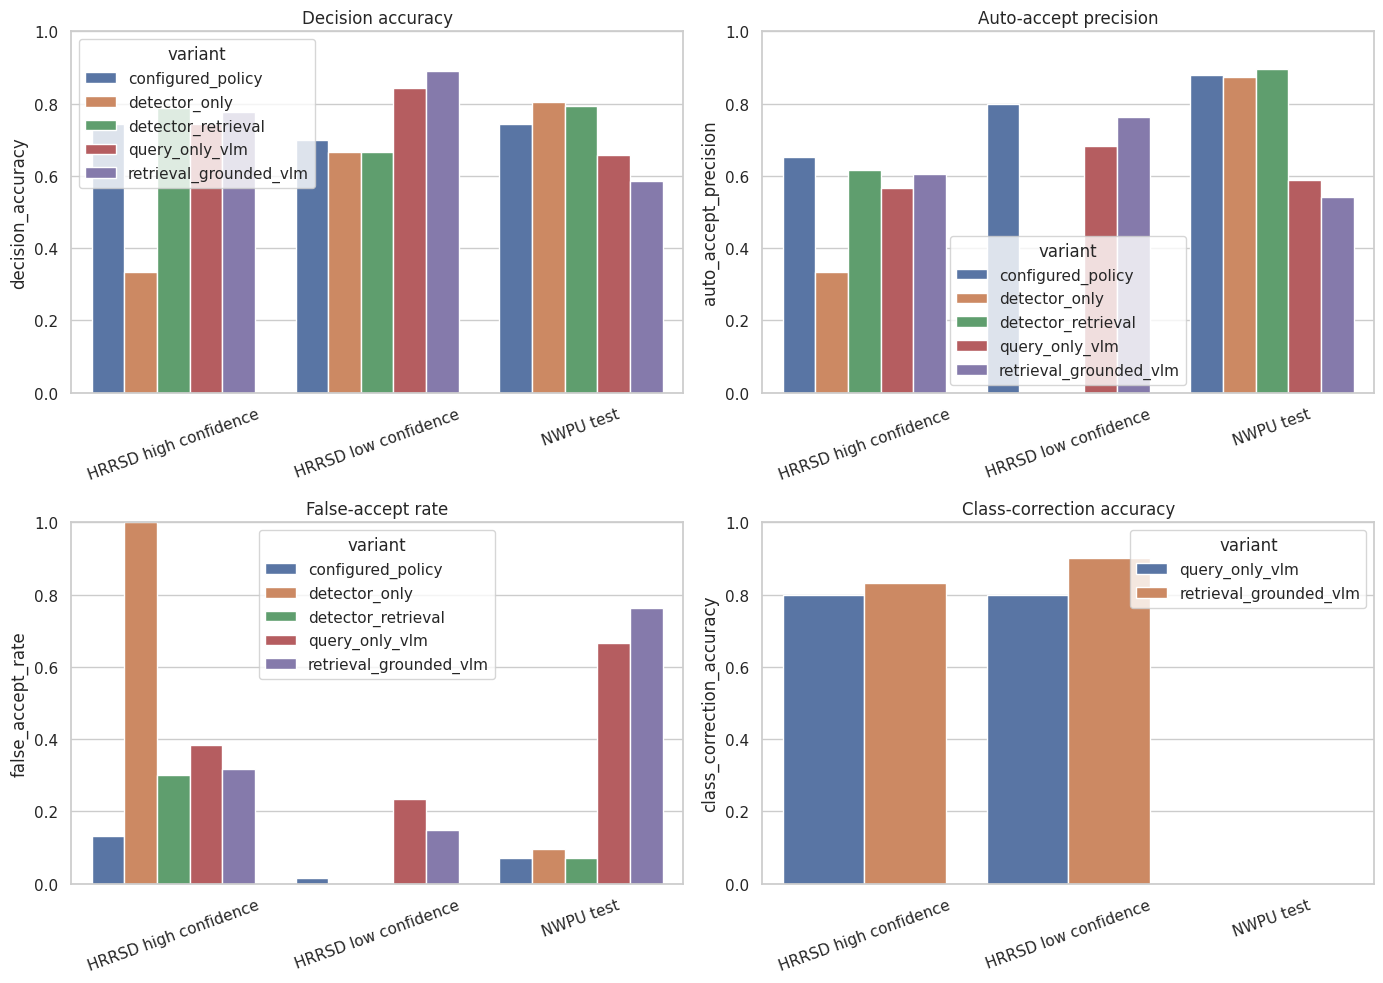

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ("decision_accuracy", "Decision accuracy"),
    ("auto_accept_precision", "Auto-accept precision"),
    ("false_accept_rate", "False-accept rate"),
    ("class_correction_accuracy", "Class-correction accuracy"),
]

for axis, (metric, title) in zip(
    axes.flat,
    metrics_to_plot,
):
    plot_frame = vlm_table.dropna(subset=[metric])

    sns.barplot(
        data=plot_frame,
        x="experiment",
        y=metric,
        hue="variant",
        ax=axis,
    )

    axis.set_ylim(0, 1)
    axis.set_title(title)
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

###These four values have clear meanings:
- potential_review_reduction: predictions not sent to humans.
- safe_automation_rate: correct automatic accepts divided by all cases.
- auto_accept_precision: reliability of automatic acceptance.
- error_deferral_rate: proportion of erroneous proposals routed to humans.

In [11]:
def load_latest_cases(experiment_directory):
    latest = {}

    with (
        experiment_directory / "case_results.jsonl"
    ).open(encoding="utf-8") as file:
        for line in file:
            if line.strip():
                record = json.loads(line)
                latest[record["case_id"]] = record

    return list(latest.values())


def policy_summary(experiment_name, experiment_directory):
    records = load_latest_cases(experiment_directory)

    completed = [
        row
        for row in records
        if row.get("run_status") == "completed"
    ]

    accepted = [
        row
        for row in completed
        if row["configured_policy"]["recommendation"]
        == "accept"
    ]

    correct_accepts = [
        row
        for row in accepted
        if row["ground_truth_status"] == "true_positive"
    ]

    false_accepts = [
        row
        for row in accepted
        if row["ground_truth_status"]
        in {"false_positive", "class_error"}
    ]

    erroneous = [
        row
        for row in completed
        if row["ground_truth_status"]
        in {"false_positive", "class_error"}
    ]

    return {
        "experiment": experiment_name,
        "cases": len(completed),
        "automatic_accepts": len(accepted),
        "correct_automatic_accepts": len(correct_accepts),
        "false_accepts": len(false_accepts),
        "potential_review_reduction": (
            len(accepted) / len(completed)
        ),
        "safe_automation_rate": (
            len(correct_accepts) / len(completed)
        ),
        "auto_accept_precision": (
            len(correct_accepts) / len(accepted)
            if accepted else None
        ),
        "error_deferral_rate": (
            (len(erroneous) - len(false_accepts))
            / len(erroneous)
            if erroneous else None
        ),
    }


workload_table = pd.DataFrame([
    policy_summary(name, directory)
    for name, directory in ASSISTANCE_RUNS.items()
])

display(
    workload_table.style.format({
        "potential_review_reduction": "{:.1%}",
        "safe_automation_rate": "{:.1%}",
        "auto_accept_precision": "{:.1%}",
        "error_deferral_rate": "{:.1%}",
    })
)

,experiment,cases,automatic_accepts,correct_automatic_accepts,false_accepts,potential_review_reduction,safe_automation_rate,auto_accept_precision,error_deferral_rate
0,NWPU test,82,25,22,3,30.5%,26.8%,88.0%,92.9%
1,HRRSD high confidence,90,23,15,8,25.6%,16.7%,65.2%,86.7%
2,HRRSD low confidence,90,5,4,1,5.6%,4.4%,80.0%,98.3%


In [12]:
decision_rows = []

for experiment, directory in ASSISTANCE_RUNS.items():
    for record in load_latest_cases(directory):
        if record.get("run_status") != "completed":
            continue

        decision_rows.append({
            "experiment": experiment,
            "ground_truth_status": (
                record["ground_truth_status"]
            ),
            "policy_recommendation": (
                record["configured_policy"][
                    "recommendation"
                ]
            ),
        })

decision_counts = (
    pd.DataFrame(decision_rows)
    .groupby(
        [
            "experiment",
            "ground_truth_status",
            "policy_recommendation",
        ]
    )
    .size()
    .rename("cases")
    .reset_index()
)

display(decision_counts)

,experiment,ground_truth_status,policy_recommendation,cases
0,HRRSD high confidence,class_error,accept,1
1,HRRSD high confidence,class_error,human_review,29
2,HRRSD high confidence,false_positive,accept,7
3,HRRSD high confidence,false_positive,human_review,23
4,HRRSD high confidence,true_positive,accept,15
5,HRRSD high confidence,true_positive,human_review,15
6,HRRSD low confidence,class_error,human_review,30
7,HRRSD low confidence,false_positive,accept,1
8,HRRSD low confidence,false_positive,human_review,29
9,HRRSD low confidence,true_positive,accept,4


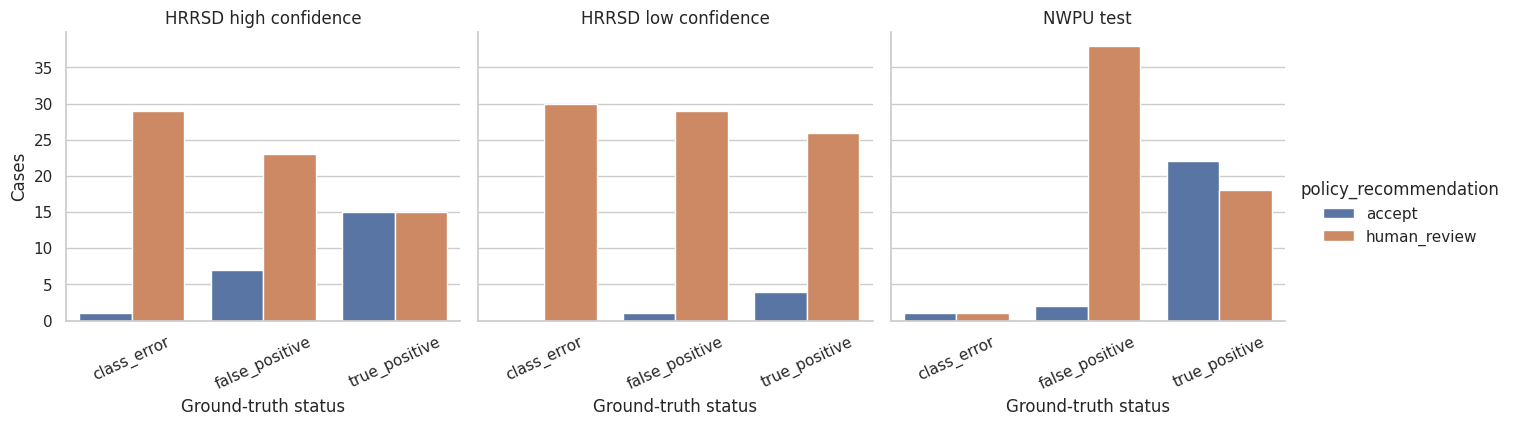

In [13]:
g = sns.catplot(
    data=decision_counts,
    x="ground_truth_status",
    y="cases",
    hue="policy_recommendation",
    col="experiment",
    kind="bar",
    height=4,
    aspect=1.1,
)

g.set_axis_labels("Ground-truth status", "Cases")
g.set_titles("{col_name}")

for axis in g.axes.flat:
    axis.tick_params(axis="x", rotation=25)

plt.show()

1. Load the case records

In [14]:
import json
import os
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

SHARED_ROOT = Path(os.environ["SHARED_RESOURCES_ROOT"])

EXPERIMENT_DIR = (
    SHARED_ROOT
    / "experiment_outputs"
    / "assistance_comparisons"
    / "hrrsd_yolov8s1024_low_confidence_rescue_seed42"
)

RESULTS_PATH = EXPERIMENT_DIR / "case_results.jsonl"
MONTAGE_DIR = EXPERIMENT_DIR / "montages"


latest = {}

with RESULTS_PATH.open(encoding="utf-8") as file:
    for line in file:
        if line.strip():
            record = json.loads(line)
            latest[record["case_id"]] = record

records = list(latest.values())

print("Cases:", len(records))

Cases: 90


2. Create an overview table

In [19]:
case_rows = []

for record in records:
    detector = record["detector"]
    query = record["query_only_vlm"]
    grounded = record["retrieval_grounded_vlm"]
    policy = record["configured_policy"]

    case_rows.append({
        "case_id": record["case_id"],
        "image_id": record["image_id"],
        "ground_truth_status": record["ground_truth_status"],
        "ground_truth_class": record["ground_truth_class_name"],
        "detector_class": detector["class_name"],
        "detector_confidence": detector["confidence"],
        "query_decision": query["decision"],
        "query_class": query["suggested_class"],
        "query_confidence": query["confidence"],
        "query_correct": query["correct"],
        "grounded_decision": grounded["decision"],
        "grounded_class": grounded["suggested_class"],
        "grounded_confidence": grounded["confidence"],
        "grounded_correct": grounded["correct"],
        "policy_recommendation": policy["recommendation"],
        "acceptance_path": policy["acceptance_path"],
        "rescue_passed": policy["rescue_passed"],
    })

cases_df = pd.DataFrame(case_rows)

display(cases_df.head())

,case_id,image_id,ground_truth_status,ground_truth_class,detector_class,detector_confidence,query_decision,query_class,query_confidence,query_correct,grounded_decision,grounded_class,grounded_confidence,grounded_correct,policy_recommendation,acceptance_path,rescue_passed
0,hrrsd_external_000007_00018_cmp_0001,hrrsd_external_000007_00018,true_positive,airplane,airplane,0.464818,accept,airplane,0.80,True,accept,airplane,0.95,True,human_review,none,False
1,hrrsd_external_000010_00031_cmp_0004,hrrsd_external_000010_00031,true_positive,storage_tank,storage_tank,0.312850,accept,storage_tank,0.95,True,accept,storage_tank,0.00,True,human_review,none,False
2,hrrsd_external_000025_00161_cmp_0002,hrrsd_external_000025_00161,true_positive,storage_tank,storage_tank,0.207280,accept,storage_tank,0.90,True,accept,storage_tank,0.95,True,accept,low_confidence_rescue,True
3,hrrsd_external_000027_00163_cmp_0003,hrrsd_external_000027_00163,true_positive,storage_tank,storage_tank,0.435743,accept,storage_tank,0.85,True,human_review,None,NaN,False,human_review,none,False
4,hrrsd_external_000031_00175_cmp_0000,hrrsd_external_000031_00175,true_positive,ship,ship,0.427658,accept,ship,0.80,True,accept,ship,0.95,True,human_review,none,False


3. Select important cases automatically

In [16]:
important_cases = {}


# A. Successful low-confidence rescue
successful_rescues = cases_df[
    (cases_df["ground_truth_status"] == "true_positive")
    & (cases_df["rescue_passed"])
]

if not successful_rescues.empty:
    important_cases["Successful rescue"] = (
        successful_rescues.iloc[0]["case_id"]
    )


# B. Retrieval corrects a class error missed by query-only VLM
retrieval_class_corrections = cases_df[
    (cases_df["ground_truth_status"] == "class_error")
    & (~cases_df["query_correct"])
    & (cases_df["grounded_correct"])
]

if not retrieval_class_corrections.empty:
    important_cases["Retrieval corrects class"] = (
        retrieval_class_corrections.iloc[0]["case_id"]
    )


# C. Query-only accepts a false positive, grounded VLM rejects it
retrieval_prevents_fp = cases_df[
    (cases_df["ground_truth_status"] == "false_positive")
    & (cases_df["query_decision"] == "accept")
    & (
        cases_df["grounded_decision"]
        .isin(["human_review", "correct"])
    )
]

if not retrieval_prevents_fp.empty:
    important_cases["Retrieval prevents false positive"] = (
        retrieval_prevents_fp.iloc[0]["case_id"]
    )


# D. Retrieval-grounded VLM still accepts a labelled false positive
grounded_failures = cases_df[
    (cases_df["ground_truth_status"] == "false_positive")
    & (cases_df["grounded_decision"] == "accept")
]

if not grounded_failures.empty:
    important_cases["Grounded VLM false accept"] = (
        grounded_failures.iloc[0]["case_id"]
    )


# E. Known likely missing HRRSD annotation
missing_annotation_id = (
    "hrrsd_external_000564_03286_cmp_0003"
)

if missing_annotation_id in latest:
    important_cases["Likely missing annotation"] = (
        missing_annotation_id
    )


important_cases

{'Successful rescue': 'hrrsd_external_000025_00161_cmp_0002',
 'Retrieval corrects class': 'hrrsd_external_000148_00843_cmp_0002',
 'Retrieval prevents false positive': 'hrrsd_external_000150_00846_cmp_0000',
 'Grounded VLM false accept': 'hrrsd_external_000065_00379_cmp_0005',
 'Likely missing annotation': 'hrrsd_external_000564_03286_cmp_0003'}

4. Display a case with its images and reasoning

In [17]:
def show_case(case_id):
    record = latest[case_id]

    detector = record["detector"]
    query = record["query_only_vlm"]
    grounded = record["retrieval_grounded_vlm"]
    policy = record["configured_policy"]

    print("=" * 90)
    print("Case:", case_id)
    print("Ground-truth status:", record["ground_truth_status"])
    print("Ground-truth class:", record["ground_truth_class_name"])
    print(
        "Detector:",
        detector["class_name"],
        f"({detector['confidence']:.3f})",
    )

    print("\nQuery-only VLM")
    print(
        "Decision:",
        query["decision"],
        "| class:",
        query["suggested_class"],
        "| confidence:",
        query["confidence"],
        "| correct:",
        query["correct"],
    )
    print(
        "Observation:",
        textwrap.fill(
            query["observations"],
            width=100,
        ),
    )
    print(
        "Uncertainty:",
        textwrap.fill(
            query["uncertainty"],
            width=100,
        ),
    )

    print("\nRetrieval-grounded VLM")
    print(
        "Decision:",
        grounded["decision"],
        "| class:",
        grounded["suggested_class"],
        "| confidence:",
        grounded["confidence"],
        "| correct:",
        grounded["correct"],
    )
    print(
        "Observation:",
        textwrap.fill(
            grounded["observations"],
            width=100,
        ),
    )
    print(
        "Uncertainty:",
        textwrap.fill(
            grounded["uncertainty"],
            width=100,
        ),
    )

    print("\nConfigured policy")
    print("Recommendation:", policy["recommendation"])
    print("Acceptance path:", policy["acceptance_path"])
    print("Rescue passed:", policy["rescue_passed"])
    print("Reasons:", policy["reasons"])

    query_montage = (
        MONTAGE_DIR
        / f"{case_id}_query_only.jpg"
    )
    grounded_montage = (
        MONTAGE_DIR
        / f"{case_id}_retrieval_grounded.jpg"
    )

    available = [
        ("Query-only input", query_montage),
        ("Retrieval-grounded input", grounded_montage),
    ]
    available = [
        (title, path)
        for title, path in available
        if path.is_file()
    ]

    fig, axes = plt.subplots(
        1,
        len(available),
        figsize=(8 * len(available), 12),
    )

    if len(available) == 1:
        axes = [axes]

    for axis, (title, path) in zip(axes, available):
        with Image.open(path) as image:
            axis.imshow(image)
        axis.set_title(title)
        axis.axis("off")

    plt.tight_layout()
    plt.show()



### Successful rescue
Case: hrrsd_external_000025_00161_cmp_0002
Ground-truth status: true_positive
Ground-truth class: storage_tank
Detector: storage_tank (0.207)

Query-only VLM
Decision: accept | class: storage_tank | confidence: 0.9 | correct: True
Observation: Global context: industrial site with multiple storage tanks and pipelines; Local object: white
cylindrical tank top visible in the blue box and crop; Evidence consistency: both Q full and Q crop
show a storage tank, matching the detector class.
Uncertainty: Low detector confidence (0.2073) but visual evidence clearly shows a storage tank; no contradictory
context.

Retrieval-grounded VLM
Decision: accept | class: storage_tank | confidence: 0.95 | correct: True
Observation: Global context: industrial site with many storage tanks and associated infrastructure; Local object:
blue box encloses a complete white circular tank top, clearly a storage tank; Evidence consistency:
Q full and Q crop both show a coherent tank, and retr

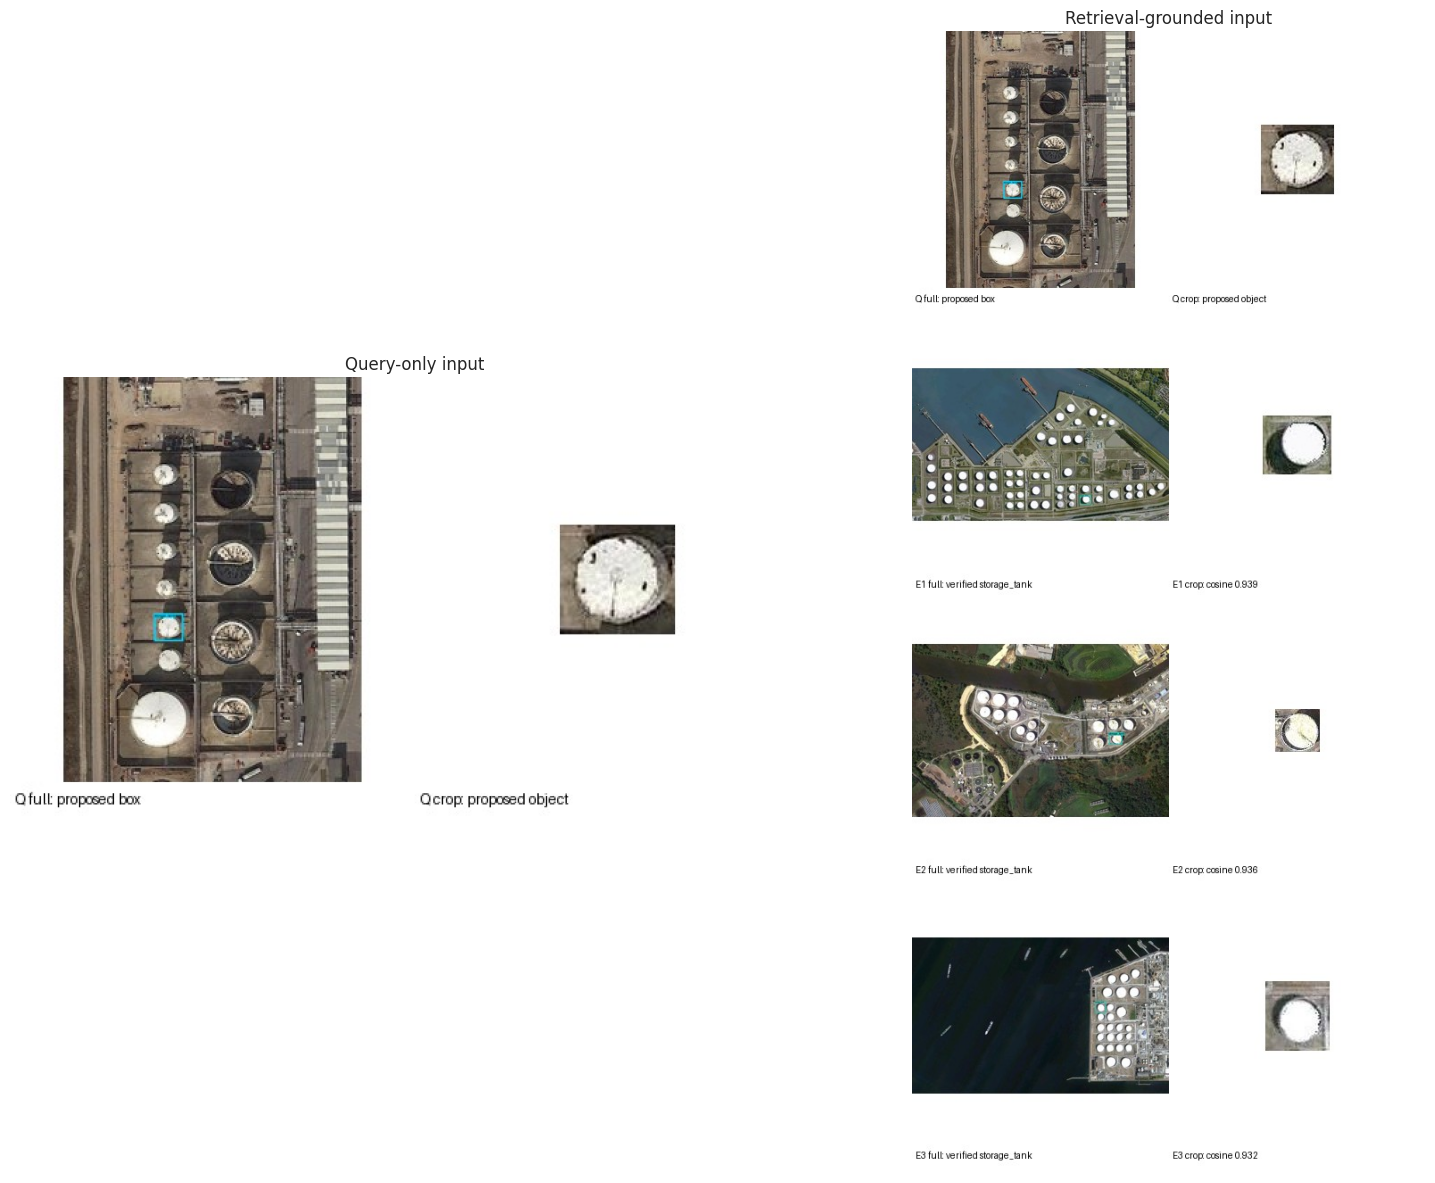



### Retrieval corrects class
Case: hrrsd_external_000148_00843_cmp_0002
Ground-truth status: class_error
Ground-truth class: storage_tank
Detector: ground_track_field (0.438)

Query-only VLM
Decision: human_review | class: None | confidence: None | correct: False
Observation: accept
Uncertainty: The VLM response was not valid structured JSON.

Retrieval-grounded VLM
Decision: correct | class: storage_tank | confidence: 0.0 | correct: True
Observation: Global context shows a storage facility with large white circular tanks; the blue box encloses two
complete tanks, and the Q crop displays a close-up of a tank roof, confirming a storage tank.
Uncertainty: The box contains two tanks rather than a single object, but each is fully visible; the detector
label (ground track field) does not match the visual evidence.

Configured policy
Recommendation: human_review
Acceptance path: none
Rescue passed: False
Reasons: ['detector confidence 0.438 is below 0.800', 'only 0 same-class neighbours ha

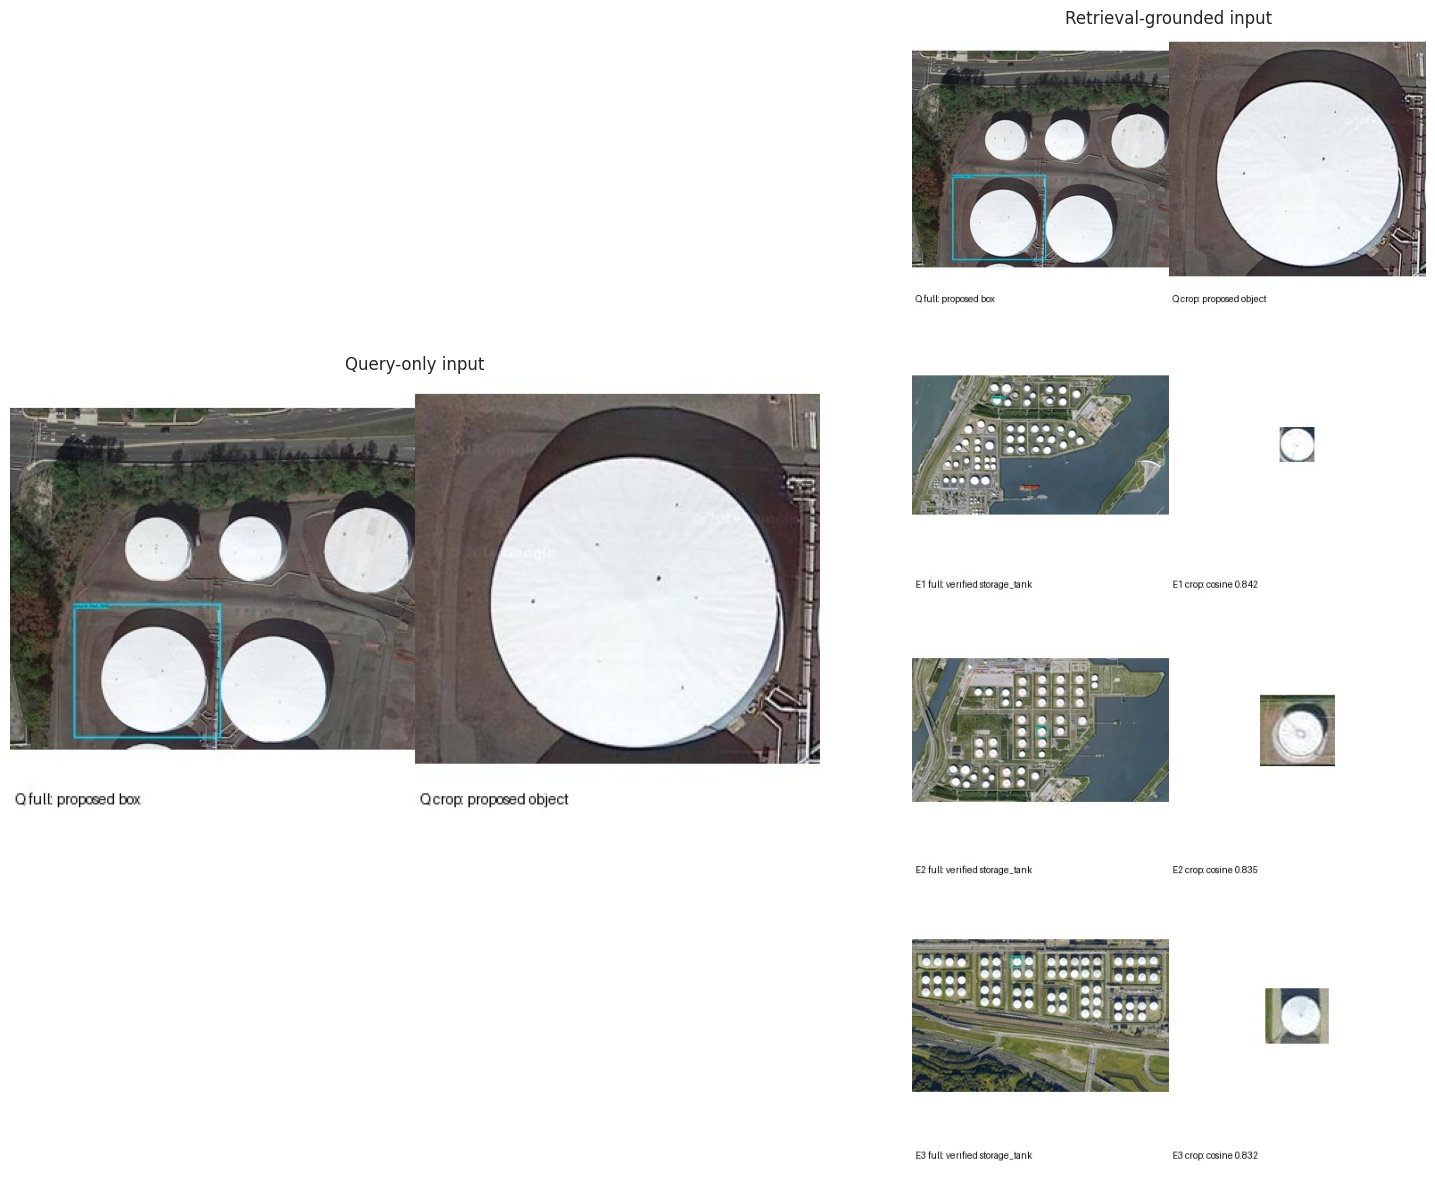



### Retrieval prevents false positive
Case: hrrsd_external_000150_00846_cmp_0000
Ground-truth status: false_positive
Ground-truth class: None
Detector: ground_track_field (0.378)

Query-only VLM
Decision: accept | class: storage_tank | confidence: 0.0 | correct: False
Observation: Global context: industrial site with four large cylindrical storage tanks in a 2x2 layout; Local
object: blue box encloses three of the tanks (top left, top right, bottom left), which are clearly
storage tanks; Evidence consistency: both full and cropped images show storage tanks matching the
class, with no contradictory elements.
Uncertainty: The box contains multiple tanks rather than a single tank, and the crop shows only two of the three
enclosed tanks, creating ambiguity about whether the target is a single tank or the group, but the
presence of storage tanks supports the class.

Retrieval-grounded VLM
Decision: correct | class: storage_tank | confidence: 0.0 | correct: False
Observation: Global contex

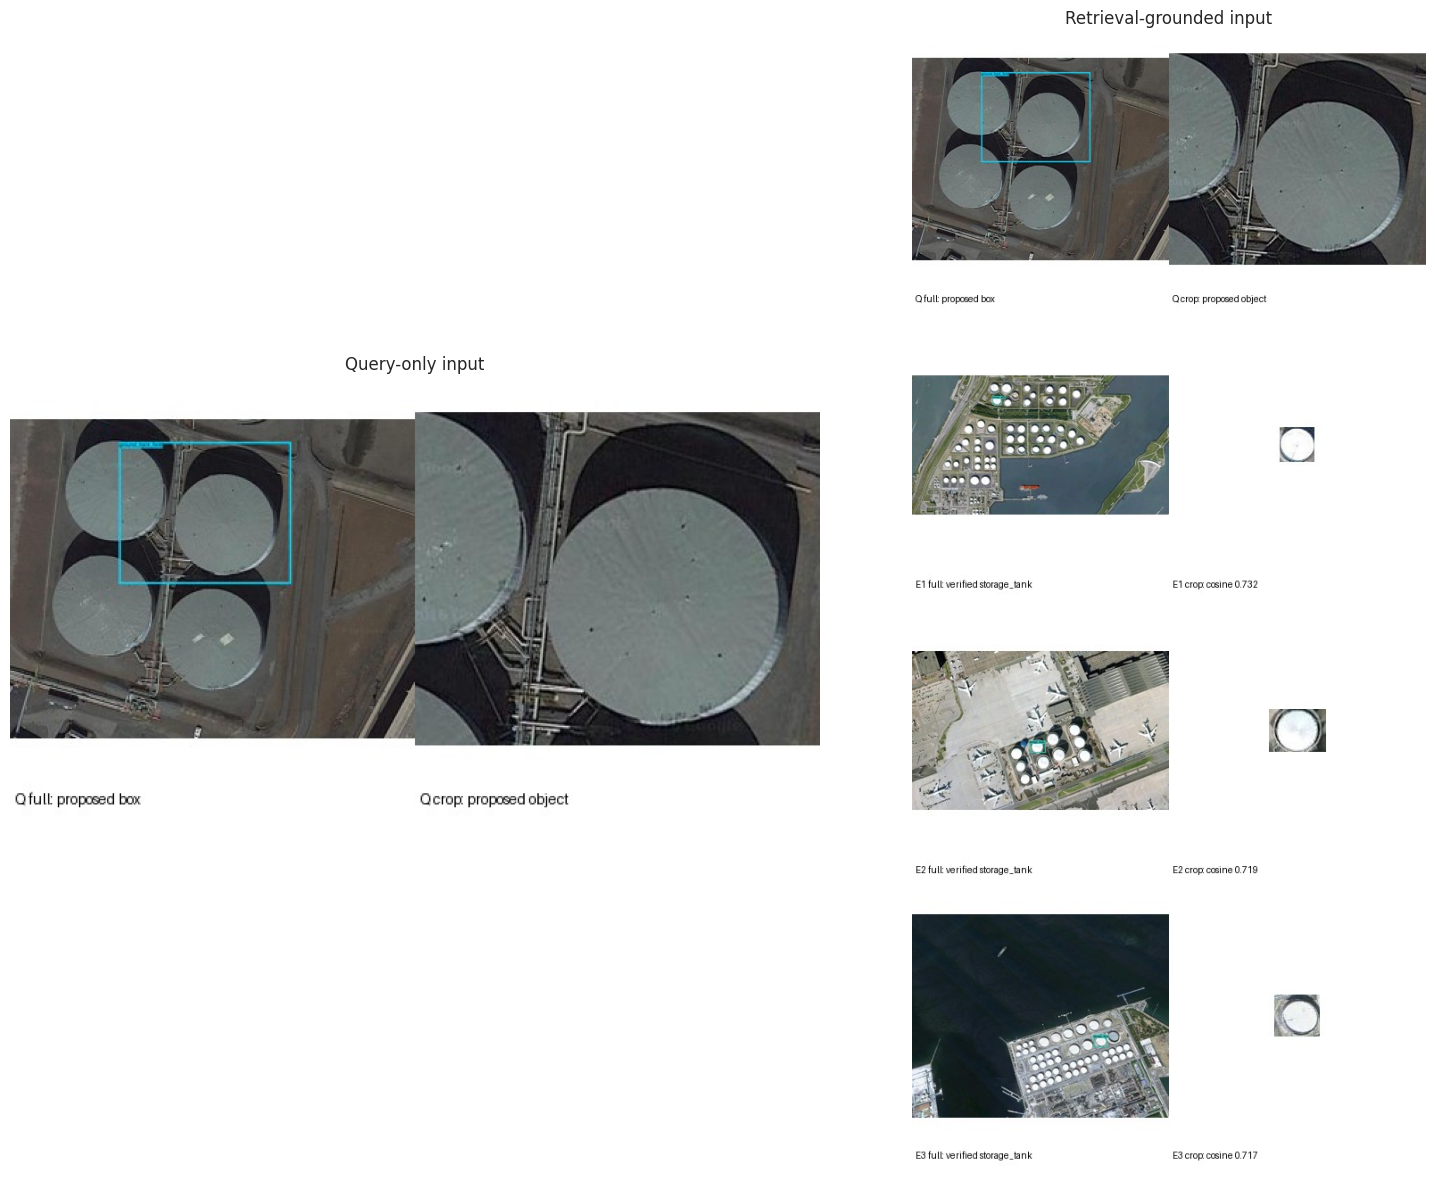



### Grounded VLM false accept
Case: hrrsd_external_000065_00379_cmp_0005
Ground-truth status: false_positive
Ground-truth class: None
Detector: storage_tank (0.418)

Query-only VLM
Decision: accept | class: storage_tank | confidence: 0.0 | correct: False
Observation: The marked box encloses a complete white-domed storage tank, clearly visible in both the full scene
and the crop, consistent with the storage tank class.
Uncertainty: None

Retrieval-grounded VLM
Decision: accept | class: storage_tank | confidence: 0.95 | correct: False
Observation: Q full shows a cluster of large white storage tanks; the blue box encloses a single complete tank; Q
crop displays a close-up of that tank, confirming it is a storage tank.
Uncertainty: None; the object is clearly a complete storage tank in both full and cropped views.

Configured policy
Recommendation: human_review
Acceptance path: none
Rescue passed: False
Reasons: ['detector confidence 0.418 is below 0.800']


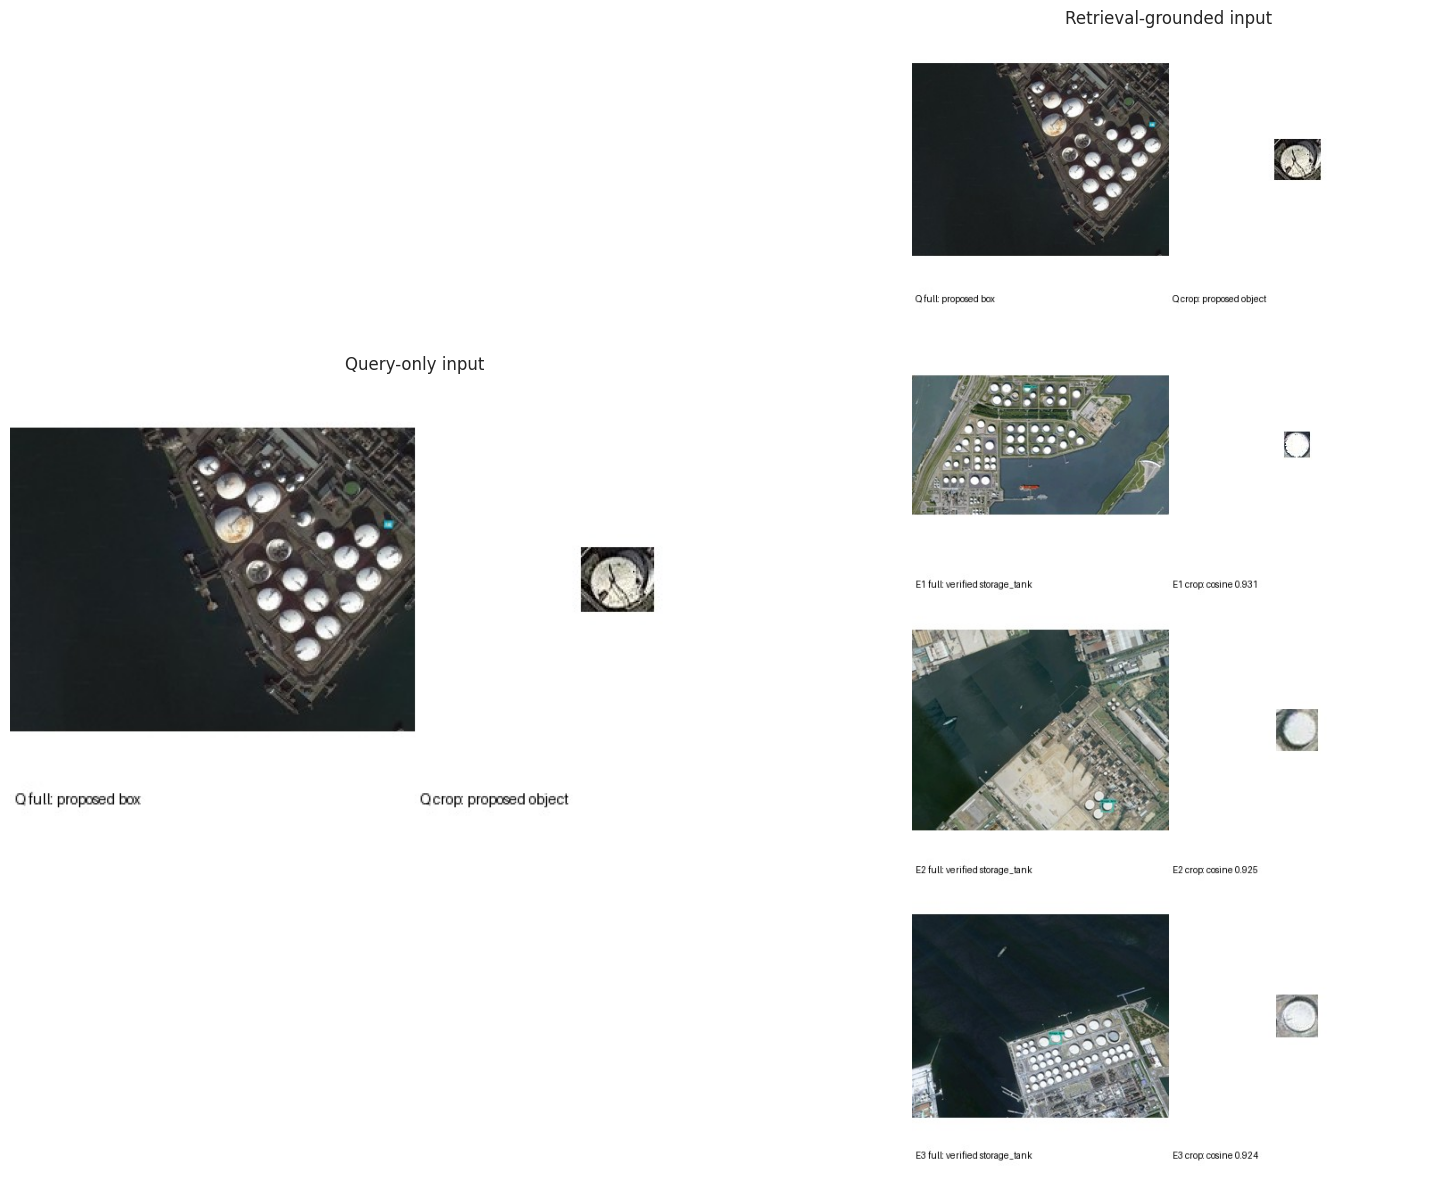



### Likely missing annotation
Case: hrrsd_external_000564_03286_cmp_0003
Ground-truth status: false_positive
Ground-truth class: None
Detector: storage_tank (0.242)

Query-only VLM
Decision: accept | class: storage_tank | confidence: 0.95 | correct: False
Observation: Global context: aerial view of an industrial site with roads, rail lines, and a large circular
structure. Local object: the marked box encloses a complete, top-down view of a large cylindrical
storage tank with a patterned roof. Evidence consistency: the Q crop shows the same coherent tank,
supporting the storage tank classification.
Uncertainty: Detector confidence is low (0.24), but visual evidence clearly shows a full storage tank, so
uncertainty is minimal.

Retrieval-grounded VLM
Decision: accept | class: storage_tank | confidence: 0.95 | correct: False
Observation: Global context: industrial site with roads and rail; Local object: large circular white storage
tank; Evidence consistency: Q full and Q crop show a co

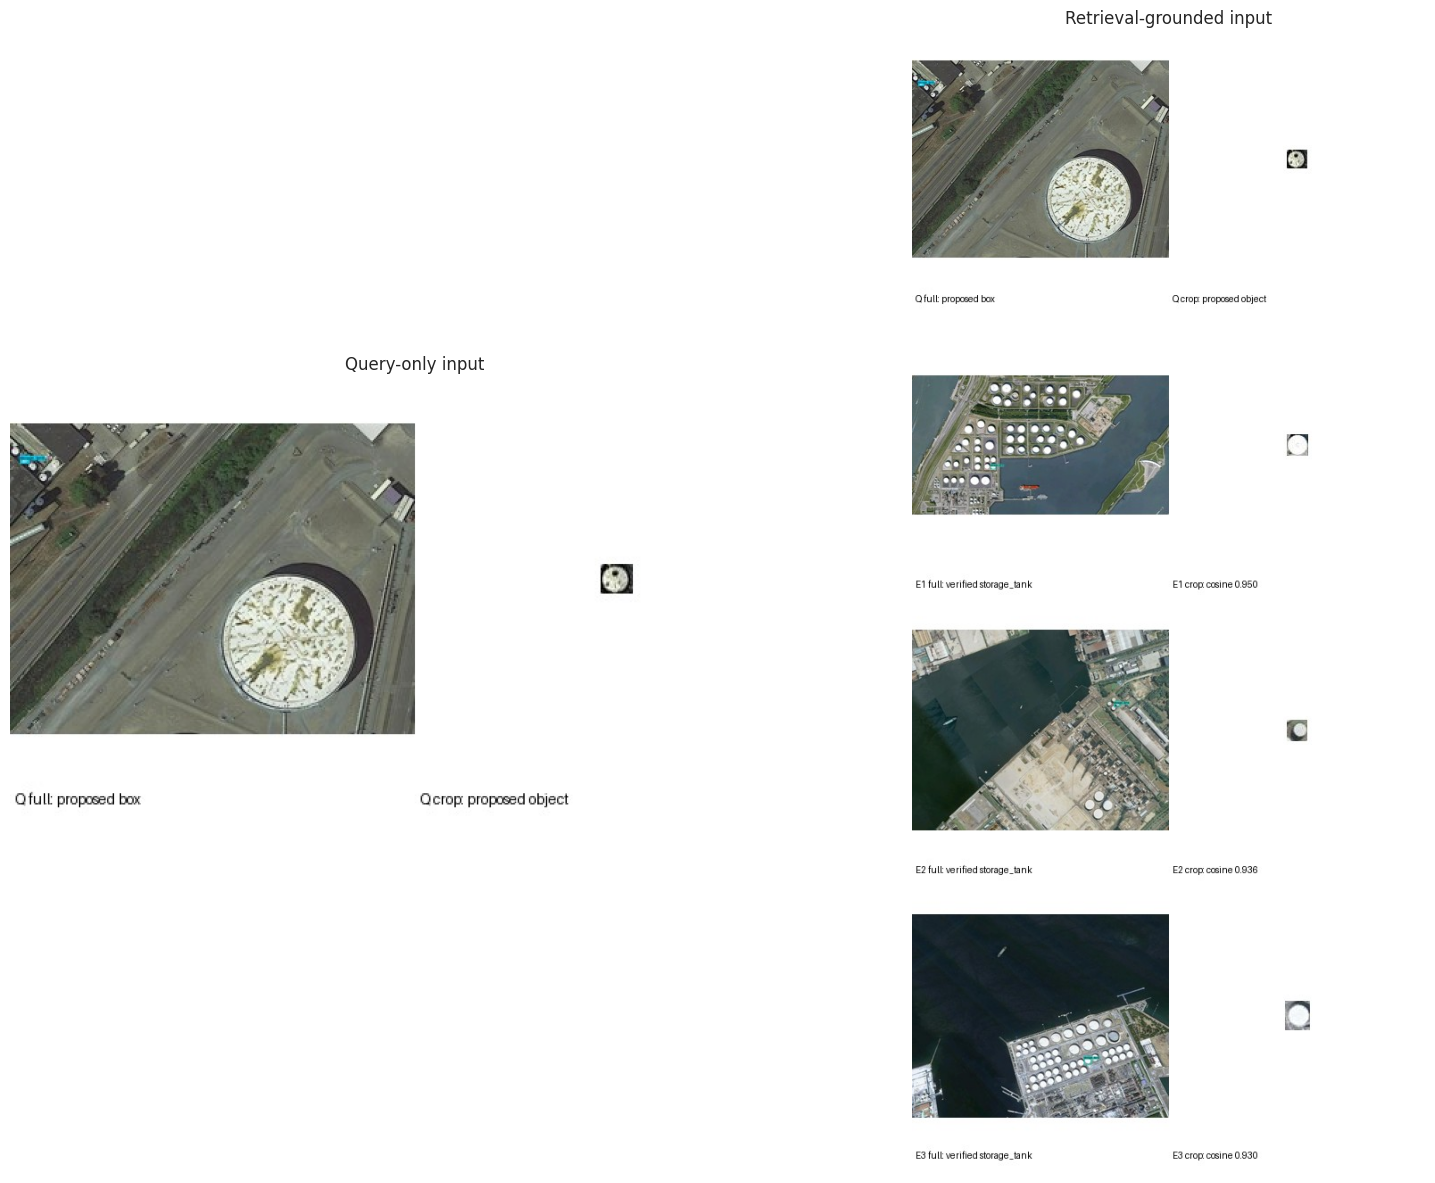

In [18]:
for category, case_id in important_cases.items():
    print(f"\n\n### {category}")
    show_case(case_id)